
# Data Preprocessing | Experiment 2-3

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv('../datasets/Housing.csv')
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no    

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


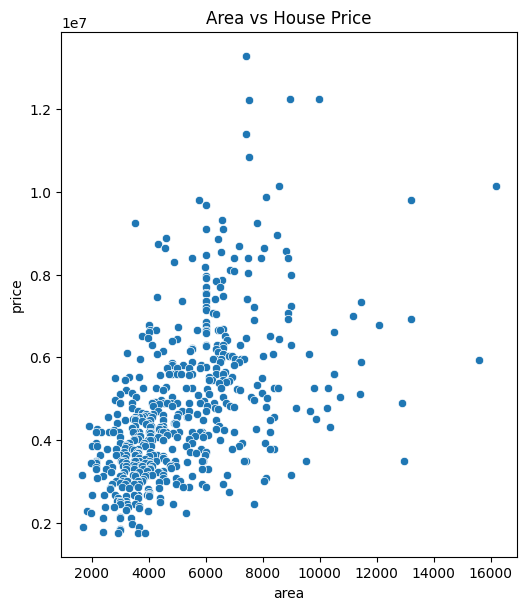

In [ ]:
print(data.describe())
features = data.columns.to_list()[1:-1]
target = data.columns.to_list()[-1]

plt.figure(figsize=(20, 15))

# plot area vs price
plt.subplot(2, 3, 1)
sns.scatterplot(x=data['area'], y=data['price'])
plt.title('Area vs House Price')
plt.show()

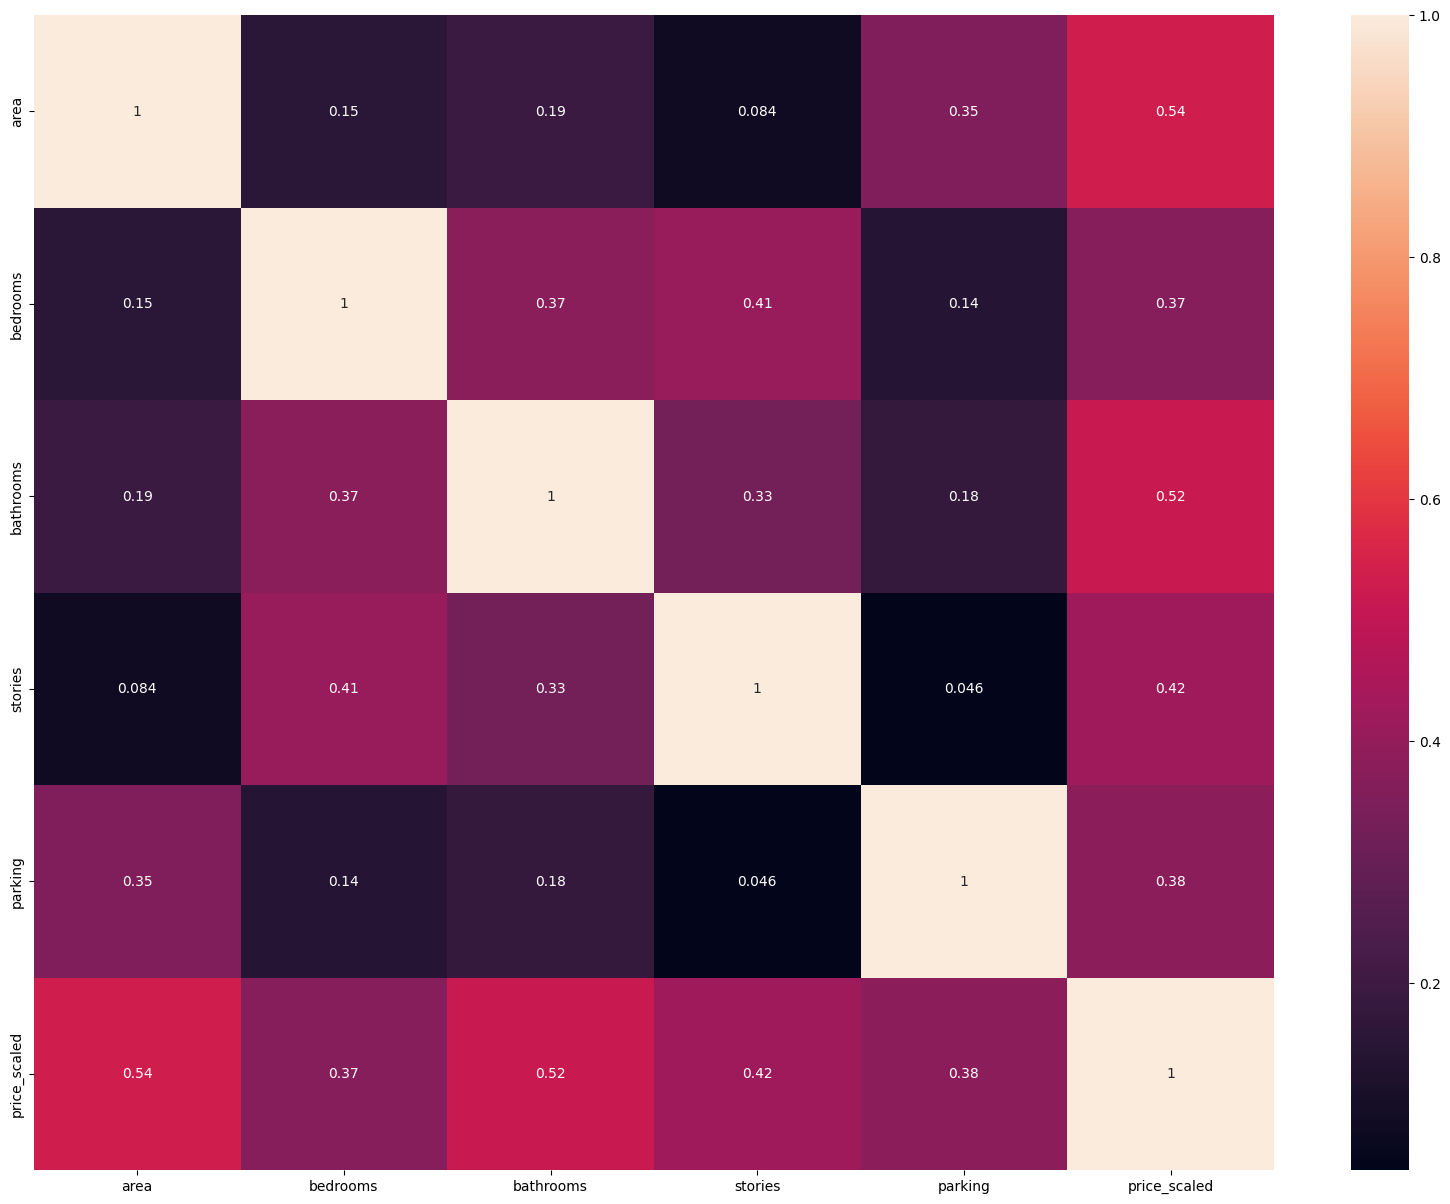

In [ ]:
# missing values handling
df = data.dropna()
df = df.drop_duplicates()

# one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']])
encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']))
df = pd.concat([df, encoded], axis=1)
df.drop(['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea'], axis=1, inplace=True)

# scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['price_scaled'] = scaler.fit_transform(df[['price']])
df['area_scaled'] = scaler.fit_transform(df[['area']])

df.to_csv('../datasets/Housing_cleaned.csv', index=False)

# corr matrix for numerical features
df = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price_scaled']]
corr = df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=True)
plt.show()
